Device: cpu

📁 Loading data...
Snow season days: 2410
Observations: 37
Features: 14

🔁 Running LOO with multi-seed averaging...

LOO Metrics (averaged over seeds)
ERA5        : MAE=19.8 mm, NSE=0.746, KGE=0.814
LSTM (avg)  : MAE=18.3 mm, NSE=0.780, KGE=0.873
GRU (avg)   : MAE=17.7 mm, NSE=0.794, KGE=0.873

✅ Metrics saved to tables\LSTM_GRU_LOO_metrics_avg_seeds.csv

🔮 Training final models on all 37 observations...
✅ Forecast saved to tables\LSTM_GRU_forecast_2022_2023_avg_seeds.csv


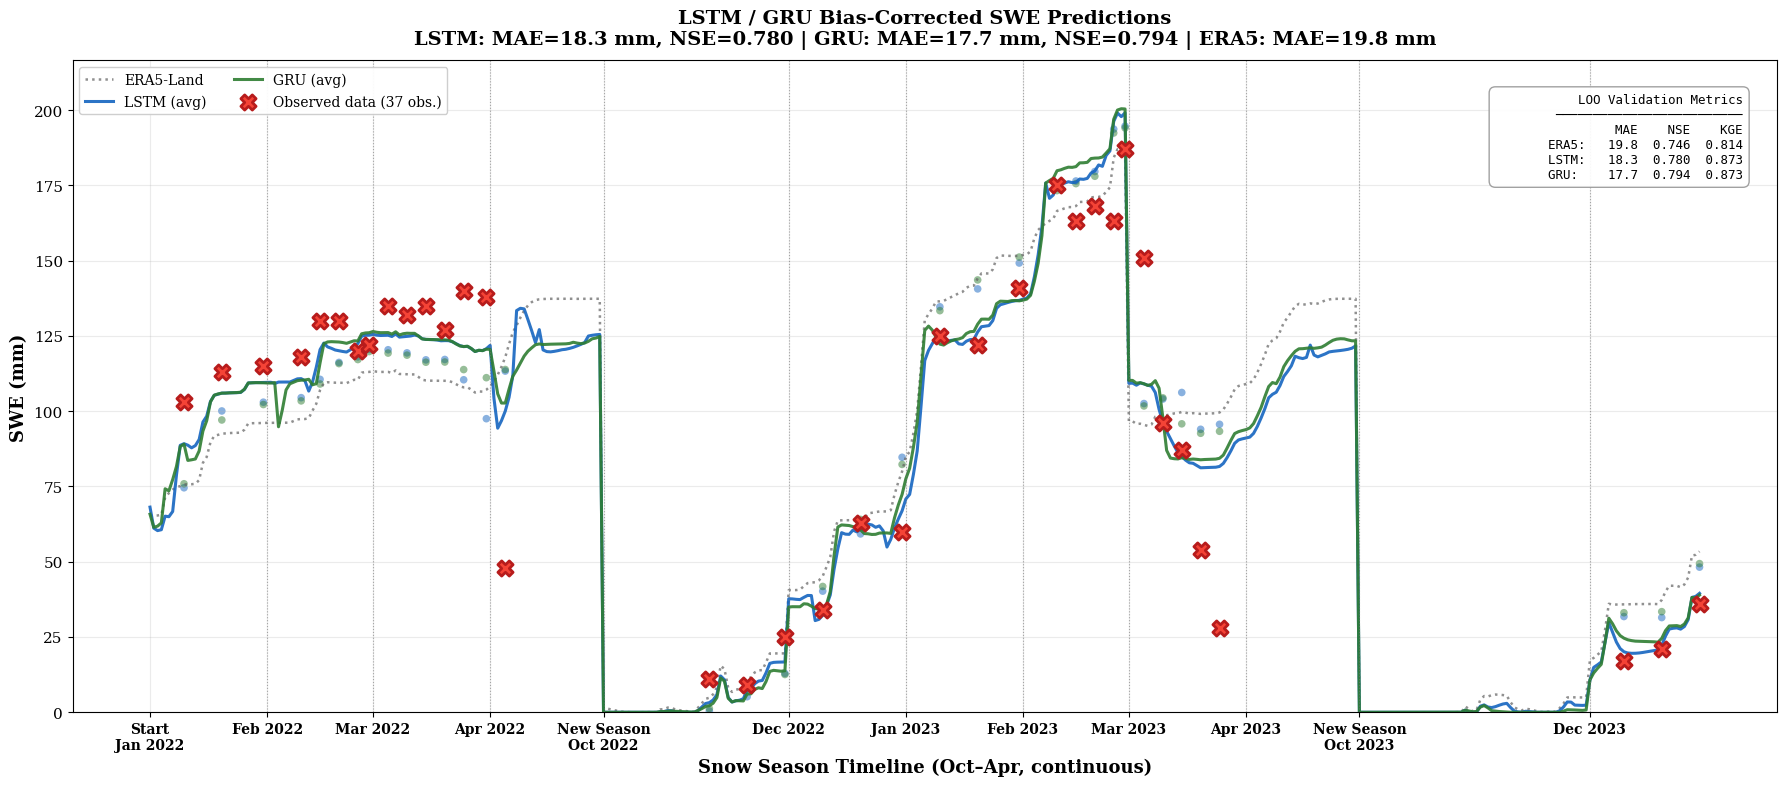

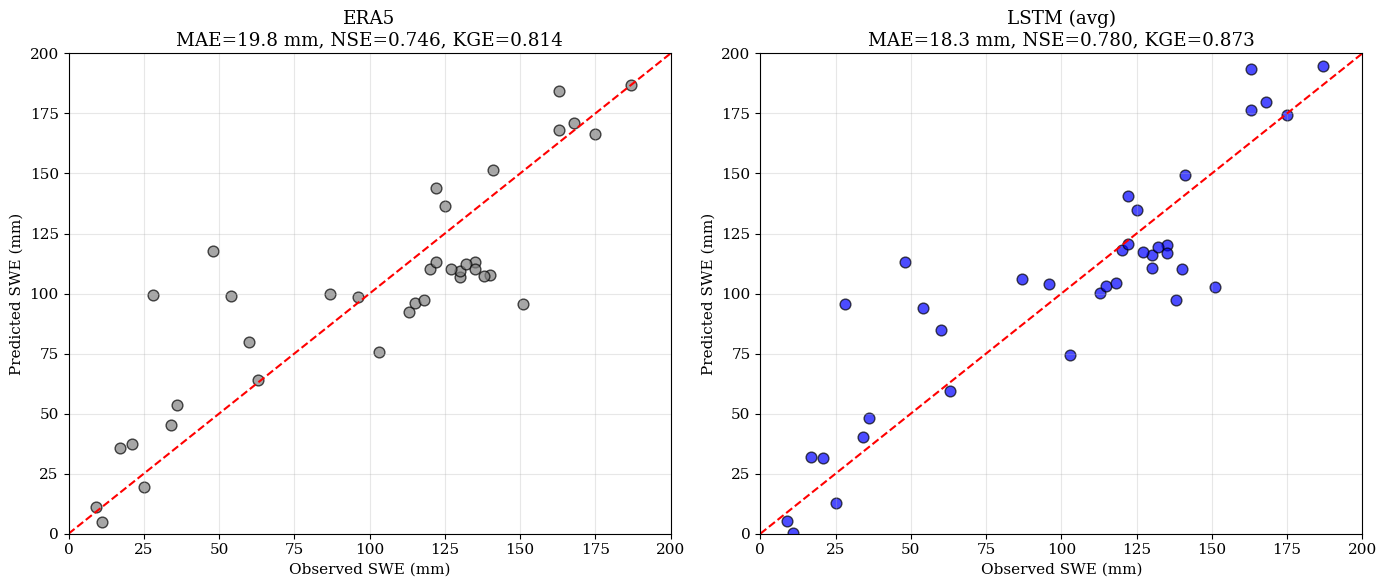

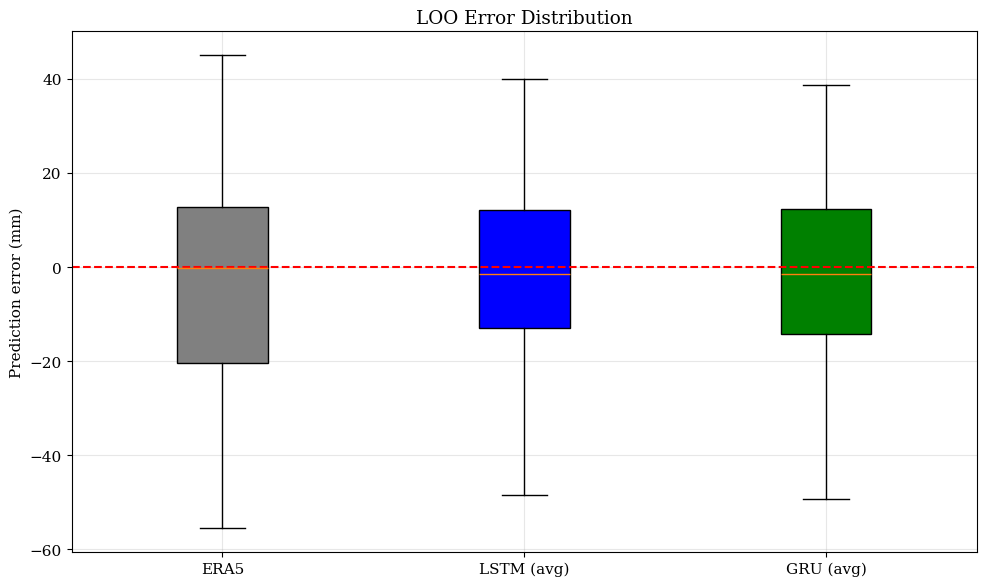


✅ All figures saved in: figures
✅ All tables saved in: tables

✨ DL LSTM/GRU analysis with seed averaging complete.


In [ ]:
# ============================================================
# LSTM / GRU for ERA5-Land SWE Bias Correction
# Leave-One-Out Validation with Multi-Seed Averaging
# Shemonaikha Region, Kazakhstan (50.62°N, 81.92°E)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
import json
import os
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEEDS = [42, 123, 456, 789, 1024]  # Fixed set of seeds for averaging
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# Create directories for figures and tables
FIG_DIR = 'figures'
TABLE_DIR = 'tables'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TABLE_DIR, exist_ok=True)

# ============================================================================
# 1. Load and prepare data
# ============================================================================
print("\n📁 Loading data...")
df = pd.read_csv("../../data_preprocessing/processed/shemonaikha_snow_dataset_2014_2023.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['era5_swe'] = df['swe_final']   # calibrated SWE

# Load station observations
obs = pd.read_csv("../../data_preprocessing/data/shemonaikha.csv")
obs['Date'] = obs['Date'].astype(str).str.replace('"', '').str.strip()
obs['Date'] = obs['Date'].str.replace(',$', '', regex=True)
obs['Date'] = pd.to_datetime(obs['Date'], format='%d.%m.%Y %H:%M')
obs['SWE'] = pd.to_numeric(obs['SWE'].astype(str).str.replace('"', '').str.replace(',', ''), errors='coerce')
obs['date'] = obs['Date'].dt.date
obs = obs.drop_duplicates(subset=['date']).copy()
obs['date'] = pd.to_datetime(obs['date'])
station_dict = dict(zip(obs['date'], obs['SWE']))
df['target_swe'] = df['date'].map(station_dict)

# Snow season only (Oct-May)
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df_snow = df[(df['month'] >= 10) | (df['month'] <= 5)].copy().reset_index(drop=True)

print(f"Snow season days: {len(df_snow)}")

# ============================================================================
# 2. Feature engineering
# ============================================================================
def create_features(df_input):
    df_out = df_input.copy()
    df_out['doy'] = df_out['date'].dt.dayofyear
    df_out['doy_sin'] = np.sin(2 * np.pi * df_out['doy'] / 365)
    df_out['doy_cos'] = np.cos(2 * np.pi * df_out['doy'] / 365)
    df_out['month_sin'] = np.sin(2 * np.pi * df_out['month'] / 12)
    df_out['month_cos'] = np.cos(2 * np.pi * df_out['month'] / 12)

    feature_cols = ['doy_sin', 'doy_cos', 'month_sin', 'month_cos',
                    'temperature_2m_C', 'precipitation_mm',
                    'snow_cover_ERA5', 'forecast_albedo']
    feature_cols = [f for f in feature_cols if f in df_out.columns]

    for feat in ['temperature_2m_C', 'precipitation_mm']:
        if feat in df_out.columns:
            for lag in [1, 2, 3]:
                col = f'{feat}_lag{lag}'
                df_out[col] = df_out[feat].shift(lag)
                feature_cols.append(col)

    for col in feature_cols:
        if col in df_out.columns:
            df_out[col] = df_out[col].fillna(method='ffill').fillna(0)

    return df_out, feature_cols

df_snow, feature_cols = create_features(df_snow)
df_obs = df_snow[df_snow['target_swe'].notna()].copy().reset_index(drop=True)
df_obs = df_obs.sort_values('date').reset_index(drop=True)

print(f"Observations: {len(df_obs)}")
print(f"Features: {len(feature_cols)}")

# ============================================================================
# 3. Model definition
# ============================================================================
class SWEPredictor(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=2, model_type='lstm', dropout=0.3):
        super().__init__()
        self.model_type = model_type
        if model_type == 'lstm':
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        else:
            self.rnn = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :])

def train_model(model, X_train, y_train, epochs=50, lr=0.001, batch_size=8, seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = model.to(DEVICE)
    dataset = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    model.train()
    for epoch in range(epochs):
        for batch_X, batch_y in loader:
            batch_X, batch_y = batch_X.to(DEVICE), batch_y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
    return model

# ============================================================================
# 4. Sequence construction
# ============================================================================
SEQ_LENGTH = 30
scaler_X = RobustScaler()
scaler_X.fit(df_snow[feature_cols].values)

def create_sequences_for_point(target_date, df_full, feature_cols, scaler, seq_length=SEQ_LENGTH):
    target_idx = df_full[df_full['date'] == target_date].index[0]
    if target_idx < seq_length:
        X_patch = df_full[feature_cols].iloc[0:target_idx+1].values
        X_patch_scaled = scaler.transform(X_patch)
        X_seq = np.zeros((seq_length, len(feature_cols)))
        X_seq[-len(X_patch_scaled):] = X_patch_scaled
    else:
        X_seq = scaler.transform(df_full[feature_cols].iloc[target_idx-seq_length+1:target_idx+1].values)
    era5_val = df_full['era5_swe'].iloc[target_idx]
    return X_seq.reshape(1, seq_length, -1), era5_val

# ============================================================================
# 5. LOO with multi-seed averaging
# ============================================================================
print("\n🔁 Running LOO with multi-seed averaging...")
loo = LeaveOneOut()
n = len(df_obs)

lstm_preds_by_seed = {seed: [] for seed in SEEDS}
gru_preds_by_seed = {seed: [] for seed in SEEDS}
y_true_list = []
dates_list = []
era5_preds = []

for fold, (train_idx, test_idx) in enumerate(loo.split(df_obs)):
    train_dates = df_obs.iloc[train_idx]['date'].values
    test_date = df_obs.iloc[test_idx]['date'].values[0]
    test_target = df_obs.iloc[test_idx]['target_swe'].values[0]
    era5_test = df_obs.iloc[test_idx]['era5_swe'].values[0]
    
    y_true_list.append(test_target)
    dates_list.append(test_date)
    era5_preds.append(era5_test)
    
    X_train_list, y_train_list = [], []
    for train_date in train_dates:
        X_seq, era5_val = create_sequences_for_point(train_date, df_snow, feature_cols, scaler_X, SEQ_LENGTH)
        target_val = df_obs[df_obs['date'] == train_date]['target_swe'].values[0]
        X_train_list.append(X_seq[0])
        y_train_list.append(target_val - era5_val)
    
    X_train_fold = np.array(X_train_list)
    y_train_fold = np.array(y_train_list).reshape(-1, 1)
    X_test_seq, _ = create_sequences_for_point(test_date, df_snow, feature_cols, scaler_X, SEQ_LENGTH)
    
    for seed in SEEDS:
        # LSTM
        model_lstm = SWEPredictor(len(feature_cols), 32, 2, 'lstm', 0.3)
        model_lstm = train_model(model_lstm, X_train_fold, y_train_fold, epochs=50, seed=seed)
        model_lstm.eval()
        with torch.no_grad():
            bias_lstm = model_lstm(torch.FloatTensor(X_test_seq).to(DEVICE)).cpu().numpy().flatten()[0]
        lstm_preds_by_seed[seed].append(max(0, era5_test + bias_lstm))
        
        # GRU
        model_gru = SWEPredictor(len(feature_cols), 32, 2, 'gru', 0.3)
        model_gru = train_model(model_gru, X_train_fold, y_train_fold, epochs=50, seed=seed)
        model_gru.eval()
        with torch.no_grad():
            bias_gru = model_gru(torch.FloatTensor(X_test_seq).to(DEVICE)).cpu().numpy().flatten()[0]
        gru_preds_by_seed[seed].append(max(0, era5_test + bias_gru))

y_true_arr = np.array(y_true_list)
era5_arr = np.array(era5_preds)

# Average predictions across seeds
lstm_mean_pred = np.mean([np.array(lstm_preds_by_seed[s]) for s in SEEDS], axis=0)
gru_mean_pred = np.mean([np.array(gru_preds_by_seed[s]) for s in SEEDS], axis=0)

# ============================================================================
# 6. Metrics
# ============================================================================
def nse(y_true, y_pred):
    return 1 - np.sum((y_true - y_pred)**2) / (np.sum((y_true - np.mean(y_true))**2) + 1e-6)

def kge(y_true, y_pred):
    r = np.corrcoef(y_true, y_pred)[0,1]
    alpha = np.std(y_pred) / (np.std(y_true) + 1e-6)
    beta = np.mean(y_pred) / (np.mean(y_true) + 1e-6)
    return 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)

def full_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    corr = np.corrcoef(y_true, y_pred)[0,1]
    nse_val = nse(y_true, y_pred)
    kge_val = kge(y_true, y_pred)
    nonzero = y_true > 0
    mape = np.mean(np.abs((y_true[nonzero] - y_pred[nonzero]) / y_true[nonzero])) * 100 if np.any(nonzero) else np.nan
    smape = np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-6)) * 100
    pbias = 100 * np.sum(y_pred - y_true) / (np.sum(y_true) + 1e-6)
    rsr = rmse / (np.std(y_true) + 1e-6)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'NSE': nse_val, 'KGE': kge_val,
            'MAPE': mape, 'SMAPE': smape, 'PBIAS': pbias, 'RSR': rsr,
            'Corr': corr}

results = {
    'ERA5': full_metrics(y_true_arr, era5_arr),
    'LSTM (avg)': full_metrics(y_true_arr, lstm_mean_pred),
    'GRU (avg)': full_metrics(y_true_arr, gru_mean_pred)
}

print("\n" + "="*80)
print("LOO Metrics (averaged over seeds)")
print("="*80)
for name, m in results.items():
    print(f"{name:12s}: MAE={m['MAE']:.1f} mm, NSE={m['NSE']:.3f}, KGE={m['KGE']:.3f}")

# Save metrics to tables/
pd.DataFrame(results).T.round(3).to_csv(os.path.join(TABLE_DIR, 'LSTM_GRU_LOO_metrics_avg_seeds.csv'))
print("\n✅ Metrics saved to", os.path.join(TABLE_DIR, 'LSTM_GRU_LOO_metrics_avg_seeds.csv'))

# ============================================================================
# 7. Final models and continuous forecast
# ============================================================================
print("\n🔮 Training final models on all 37 observations...")
X_all_list, y_all_list = [], []
for _, row in df_obs.iterrows():
    X_seq, era5_val = create_sequences_for_point(row['date'], df_snow, feature_cols, scaler_X, SEQ_LENGTH)
    X_all_list.append(X_seq[0])
    y_all_list.append(row['target_swe'] - era5_val)

X_all = np.array(X_all_list)
y_all = np.array(y_all_list).reshape(-1, 1)

mask_forecast = (df_snow['year'] >= 2022) & (df_snow['year'] <= 2023)
df_forecast = df_snow[mask_forecast].copy().reset_index(drop=True)

forecast_dates = df_forecast['date'].values
forecast_era5 = df_forecast['era5_swe'].values
forecast_target = df_forecast['target_swe'].values
lstm_forecast_by_seed = {seed: [] for seed in SEEDS}
gru_forecast_by_seed = {seed: [] for seed in SEEDS}

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)
    final_lstm = SWEPredictor(len(feature_cols), 32, 2, 'lstm', 0.3)
    final_lstm = train_model(final_lstm, X_all, y_all, epochs=75, seed=seed)
    final_gru = SWEPredictor(len(feature_cols), 32, 2, 'gru', 0.3)
    final_gru = train_model(final_gru, X_all, y_all, epochs=75, seed=seed)
    
    final_lstm.eval()
    final_gru.eval()
    for date, era5_val in zip(forecast_dates, forecast_era5):
        X_seq, _ = create_sequences_for_point(date, df_snow, feature_cols, scaler_X, SEQ_LENGTH)
        with torch.no_grad():
            bias_lstm = final_lstm(torch.FloatTensor(X_seq).to(DEVICE)).cpu().numpy().flatten()[0]
            bias_gru = final_gru(torch.FloatTensor(X_seq).to(DEVICE)).cpu().numpy().flatten()[0]
        lstm_forecast_by_seed[seed].append(max(0, era5_val + bias_lstm))
        gru_forecast_by_seed[seed].append(max(0, era5_val + bias_gru))

lstm_forecast_mean = np.mean([np.array(lstm_forecast_by_seed[s]) for s in SEEDS], axis=0)
gru_forecast_mean = np.mean([np.array(gru_forecast_by_seed[s]) for s in SEEDS], axis=0)

# Save forecast to tables/
pd.DataFrame({
    'date': forecast_dates,
    'target_swe': forecast_target,
    'ERA5': forecast_era5,
    'LSTM_avg': lstm_forecast_mean,
    'GRU_avg': gru_forecast_mean
}).to_csv(os.path.join(TABLE_DIR, 'LSTM_GRU_forecast_2022_2023_avg_seeds.csv'), index=False)
print("✅ Forecast saved to", os.path.join(TABLE_DIR, 'LSTM_GRU_forecast_2022_2023_avg_seeds.csv'))

# ============================================================================
# 8. Publication-quality figures
# ============================================================================
plt.rcParams.update({'font.size': 11, 'font.family': 'serif', 'mathtext.fontset': 'stix'})

# ============================================================================
# 8.1 Time series (Oct-Apr, continuous, no background shading)
# ============================================================================
dates_dt = pd.to_datetime(forecast_dates)
months = dates_dt.month.values
years = dates_dt.year.values

# Only Oct–Apr
snow_mask = (months >= 10) | (months <= 4)
snow_indices = np.where(snow_mask)[0]
x_cont = np.arange(len(snow_indices))

# Filter data
era5_snow = forecast_era5[snow_indices]
lstm_snow = lstm_forecast_mean[snow_indices]
gru_snow = gru_forecast_mean[snow_indices]
target_snow = forecast_target[snow_indices]
mask_obs_snow = ~np.isnan(target_snow)

# Map LOO dates to continuous x-axis
loo_dates_dt = pd.to_datetime(dates_list)
loo_x = []
for loo_date in loo_dates_dt:
    diff = np.abs(dates_dt - loo_date)
    if diff.min() < pd.Timedelta(days=1):
        orig_idx = np.argmin(diff)
        if orig_idx in set(snow_indices):
            cont_idx = np.where(snow_indices == orig_idx)[0][0]
            loo_x.append(cont_idx)
        else:
            loo_x.append(None)
    else:
        loo_x.append(None)
loo_x = np.array([x for x in loo_x if x is not None])

fig, ax = plt.subplots(figsize=(18, 8))

# Forecast lines
ax.plot(x_cont, era5_snow, color='#616161', linestyle=':', linewidth=1.8,
        label='ERA5-Land', alpha=0.7)
ax.plot(x_cont, lstm_snow, color='#1565C0', linewidth=2.2,
        label='LSTM (avg)', alpha=0.9)
ax.plot(x_cont, gru_snow, color='#2E7D32', linewidth=2.2,
        label='GRU (avg)', alpha=0.9)

# LOO predictions (small dots)
for xi, l_pred, g_pred in zip(loo_x, lstm_mean_pred, gru_mean_pred):
    ax.scatter(xi, l_pred, color='#1565C0', s=30, alpha=0.5, edgecolors='none')
    ax.scatter(xi, g_pred, color='#2E7D32', s=30, alpha=0.5, edgecolors='none')

# Station observations
ax.scatter(x_cont[mask_obs_snow], target_snow[mask_obs_snow],
            marker='X', s=120, color='#F44336', label='Observed data (37 obs.)',
            zorder=10, linewidth=2.0, edgecolors='#B71C1C')

# Season labels
season_labels = []
season_positions = []
prev_month = None
for i, idx in enumerate(snow_indices):
    month = dates_dt[idx].month
    year = dates_dt[idx].year
    if i == 0:
        label = f"Start\n{dates_dt[idx].strftime('%b %Y')}"
        season_labels.append(label)
        season_positions.append(i)
    elif month == 10 and prev_month and prev_month <= 4:
        label = f"New Season\nOct {year}"
        season_labels.append(label)
        season_positions.append(i)
    elif month == 12 and prev_month == 11:
        label = f"Dec {year}"
        season_labels.append(label)
        season_positions.append(i)
    elif month == 1 and prev_month == 12:
        label = f"Jan {year}"
        season_labels.append(label)
        season_positions.append(i)
    elif month == 2 and prev_month == 1:
        label = f"Feb {year}"
        season_labels.append(label)
        season_positions.append(i)
    elif month == 3 and prev_month == 2:
        label = f"Mar {year}"
        season_labels.append(label)
        season_positions.append(i)
    elif month == 4 and prev_month == 3:
        label = f"Apr {year}"
        season_labels.append(label)
        season_positions.append(i)
    prev_month = month

# Vertical dashed lines
for pos in season_positions[1:]:
    ax.axvline(x=pos, color='#757575', linestyle=':', linewidth=0.8, alpha=0.6)

ax.set_xticks(season_positions)
ax.set_xticklabels(season_labels, rotation=0, ha='center', fontsize=10, fontweight='bold')
ax.set_xlabel('Snow Season Timeline (Oct–Apr, continuous)', fontsize=13, fontweight='bold')
ax.set_ylabel('SWE (mm)', fontsize=13, fontweight='bold')
ax.set_ylim(0, np.nanmax(np.concatenate([era5_snow, lstm_snow, gru_snow, target_snow[mask_obs_snow]])) * 1.08)

# Title
m_era = results['ERA5']
m_lstm = results['LSTM (avg)']
m_gru = results['GRU (avg)']
ax.set_title(f'LSTM / GRU Bias-Corrected SWE Predictions\n'
            f'LSTM: MAE={m_lstm["MAE"]:.1f} mm, NSE={m_lstm["NSE"]:.3f} | '
            f'GRU: MAE={m_gru["MAE"]:.1f} mm, NSE={m_gru["NSE"]:.3f} | '
            f'ERA5: MAE={m_era["MAE"]:.1f} mm',
            fontsize=14, fontweight='bold', pad=12)

ax.grid(True, alpha=0.25)
ax.legend(loc='upper left', fontsize=10, framealpha=0.95, ncol=2)

# Text box with metrics
textstr = (f'LOO Validation Metrics\n'
            f'{"─" * 25}\n'
            f'{"":<12} {"MAE":>6} {"NSE":>6} {"KGE":>6}\n'
            f'ERA5:  {m_era["MAE"]:>5.1f}  {m_era["NSE"]:>5.3f}  {m_era["KGE"]:>5.3f}\n'
            f'LSTM:  {m_lstm["MAE"]:>5.1f}  {m_lstm["NSE"]:>5.3f}  {m_lstm["KGE"]:>5.3f}\n'
            f'GRU:   {m_gru["MAE"]:>5.1f}  {m_gru["NSE"]:>5.3f}  {m_gru["KGE"]:>5.3f}')
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.92, edgecolor='#999999')
ax.text(0.98, 0.95, textstr, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', horizontalalignment='right', bbox=props,
        family='monospace')

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Figure_timeseries_LSTM_GRU_Oct_Apr.png'), dpi=300)
plt.savefig(os.path.join(FIG_DIR, 'Figure_timeseries_LSTM_GRU_Oct_Apr.pdf'))
plt.show()

# 8.2 Scatter plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for i, (name, pred, color) in enumerate([('ERA5', era5_arr, 'gray'), ('LSTM (avg)', lstm_mean_pred, 'blue')]):
    axes[i].scatter(y_true_arr, pred, alpha=0.7, edgecolors='k', s=60, color=color)
    axes[i].plot([0, 200], [0, 200], 'r--', lw=1.5)
    axes[i].set_xlim(0, 200); axes[i].set_ylim(0, 200)
    axes[i].set_xlabel('Observed SWE (mm)'); axes[i].set_ylabel('Predicted SWE (mm)')
    m = results[name]
    axes[i].set_title(f"{name}\nMAE={m['MAE']:.1f} mm, NSE={m['NSE']:.3f}, KGE={m['KGE']:.3f}")
    axes[i].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Figure_scatter_avg_seeds.png'), dpi=300)
plt.show()

# 8.3 Error boxplot
fig, ax = plt.subplots(figsize=(10, 6))
errors = [era5_arr - y_true_arr, lstm_mean_pred - y_true_arr, gru_mean_pred - y_true_arr]
bp = ax.boxplot(errors, labels=['ERA5', 'LSTM (avg)', 'GRU (avg)'], patch_artist=True, showfliers=False)
colors = ['gray', 'blue', 'green']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_ylabel('Prediction error (mm)')
ax.set_title('LOO Error Distribution')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Figure_boxplot_errors_avg_seeds.png'), dpi=300)
plt.show()

print("\n✅ All figures saved in:", FIG_DIR)
print("✅ All tables saved in:", TABLE_DIR)
print("\n✨ DL LSTM/GRU analysis with seed averaging complete.")

Points show leave-one-out (LOO) predictions, where each point was withheld from training. Continuous lines represent the final model reconstruction after training on all 37 observations.